# Model Interpretation

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from boosting_utils import (
    FEATURES, baseline_models, ensure_output_dir, fit_best_classifier, fit_regressor,
    long_short_backtest, make_boosting_panel, make_intraday_features, model_interpretation,
    score_quantiles, tune_gbm
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
panel = make_boosting_panel(seed=127)
model, scored, metrics = fit_best_classifier(panel)
importance, partial = model_interpretation(model, panel)
importance.to_csv(OUTPUT / 'gbm_permutation_importance.csv', index=False)
partial.to_csv(OUTPUT / 'gbm_partial_dependence.csv', index=False)
importance

,feature,importance
5,quality,0.0113
3,volatility_21,0.0077
2,momentum_63,0.0036
6,value,0.0014
1,momentum_21,0.0010
4,volume_z,-0.0003
0,momentum_10,-0.0015


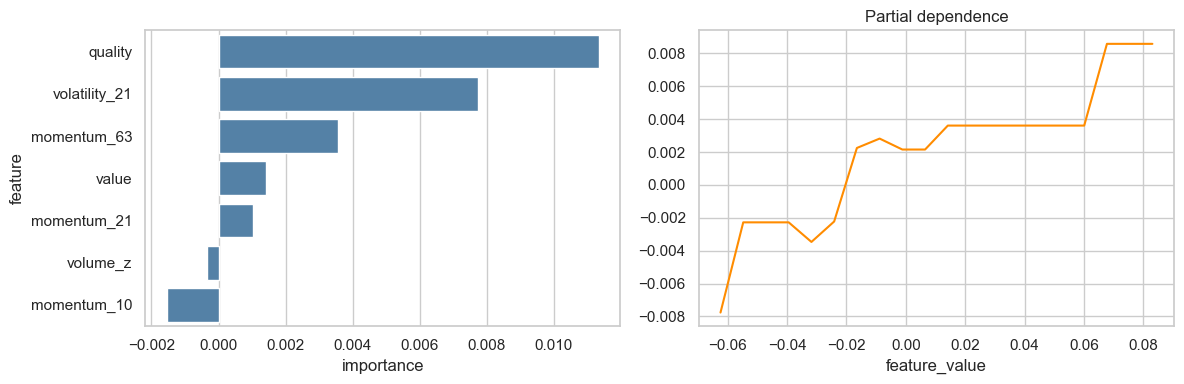

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=importance, x='importance', y='feature', ax=axes[0], color='steelblue')
partial.plot(x='feature_value', y='partial_dependence', ax=axes[1], legend=False, color='darkorange')
axes[1].set_title('Partial dependence')
plt.tight_layout()